# Statistical Learning and Data Analysis - Assignment 2
## Probability Models Comparison: Exponential and Poisson

This notebook presents a comparative analysis of the Poisson and Exponential distributions. It investigates their theoretical properties, parameter sensitivity, asymptotic convergence to the Gaussian model, and applicability to real-world scenarios.

---

## 1. Theoretical Comparison
### 1.1 Probability Models

#### **The Poisson Distribution**
The Poisson distribution models the count of independent events occurring in a fixed interval of time or space at a constant average rate.

* **PMF (Probability Mass Function):**
    $$P(X = k) = \frac{\lambda^k e^{-\lambda}}{k!}, \quad k \in \{0, 1, 2, \dots\}$$

* **Parameter Descriptions:**
    * **$\lambda$ (Lambda):** The **expected rate** or average number of occurrences in the specified fixed interval. It serves as both the mean and the variance of the distribution. ($\lambda > 0$)
    * **$k$:** The discrete random variable representing the **number of occurrences** (or count of events) you are interested in. It must be a non-negative integer ($0, 1, 2, \dots$).
    * **$e$:** Euler's number ($\approx 2.71828$), the base of the natural logarithm.

#### **The Exponential Distribution**
The Exponential distribution models the continuous time interval between consecutive events in a Poisson process. It is the only continuous distribution with the "memoryless" property.

* **PDF (Probability Density Function):**
    $$f(x; \lambda) = \lambda e^{-\lambda x}, \quad x \ge 0$$

* **Parameter Descriptions:**
    * **$\lambda$ (Lambda):** The **rate parameter**, representing the average number of events per unit of time. (This is the reciprocal of the mean, $\mu = 1/\lambda$).
    * **$x$:** The continuous random variable representing the **time duration** or space interval until the next event occurs. ($x \ge 0$)

### 1.2 Moments and Parameter Dependence

| Statistic | Poisson ($X$) | Exponential ($T$) | Dependence on $\lambda$ |
| :--- | :--- | :--- | :--- |
| **Mean** | $E[X] = \lambda$ | $E[T] = \frac{1}{\lambda}$ | Poisson mean increases with rate; Exponential mean decreases. |
| **Variance** | $Var(X) = \lambda$ | $Var(T) = \frac{1}{\lambda^2}$ | Poisson spread increases with rate; Exponential spread decreases (intervals become more consistent). |

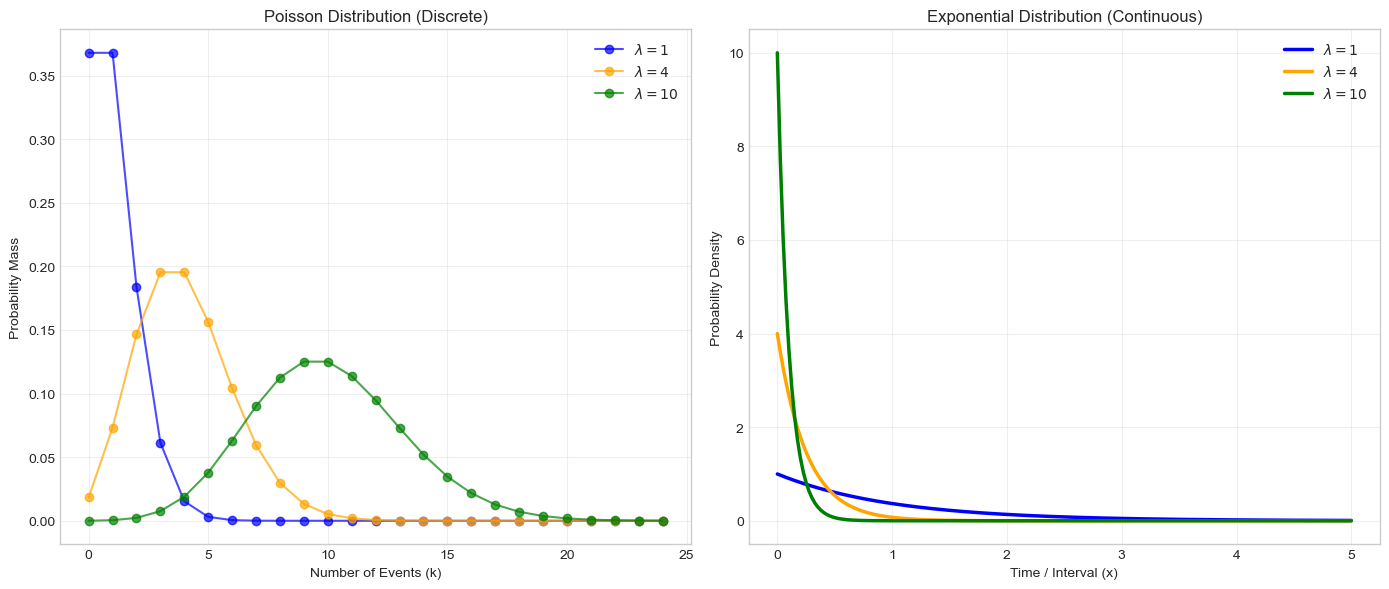

In [39]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson, expon


lambdas = [1, 4, 10] 
colors = ['blue', 'orange', 'green']
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
x_p = np.arange(0, 25)

for lam, col in zip(lambdas, colors):
    plt.plot(x_p, poisson.pmf(x_p, lam), marker='o', linestyle='-', 
             color=col, label=f'$\lambda={lam}$', alpha=0.7)

plt.title('Poisson Distribution (Discrete)')
plt.xlabel('Number of Events (k)')
plt.ylabel('Probability Mass')
plt.legend()
plt.grid(True, alpha=0.3)
plt.subplot(1, 2, 2)
x_e = np.linspace(0, 5, 200)

for lam, col in zip(lambdas, colors):
    plt.plot(x_e, expon.pdf(x_e, scale=1/lam), 
             color=col, lw=2.5, label=f'$\lambda={lam}$')

plt.title('Exponential Distribution (Continuous)')
plt.xlabel('Time / Interval (x)')
plt.ylabel('Probability Density')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 1.3 Shape and Parameter Sensitivity

**Poisson:**
* **Skewness:** $1/\sqrt{\lambda}$. For low $\lambda$, the distribution is heavily right-skewed. As $\lambda$ increases, skewness approaches 0 (symmetry).
* **Spread:** Standard deviation is $\sqrt{\lambda}$. The distribution widens as the rate increases.

**Exponential:**
* **Skewness:** Always 2. The distribution is always strongly right-skewed regardless of $\lambda$.
* **Spread:** Standard deviation is $1/\lambda$. The distribution becomes narrower and steeper as the rate increases.

### 1.4 Real-World Interpretation

* **Poisson Context:** Used when asking "How many?" in a fixed window (e.g., number of emails arriving per hour).
* **Exponential Context:** Used when asking "How long?" until the next event (e.g., time between two email arrivals).
* **Distinction:** Poisson is discrete (counts); Exponential is continuous (intervals). They describe the same underlying process but focus on different dimensions.

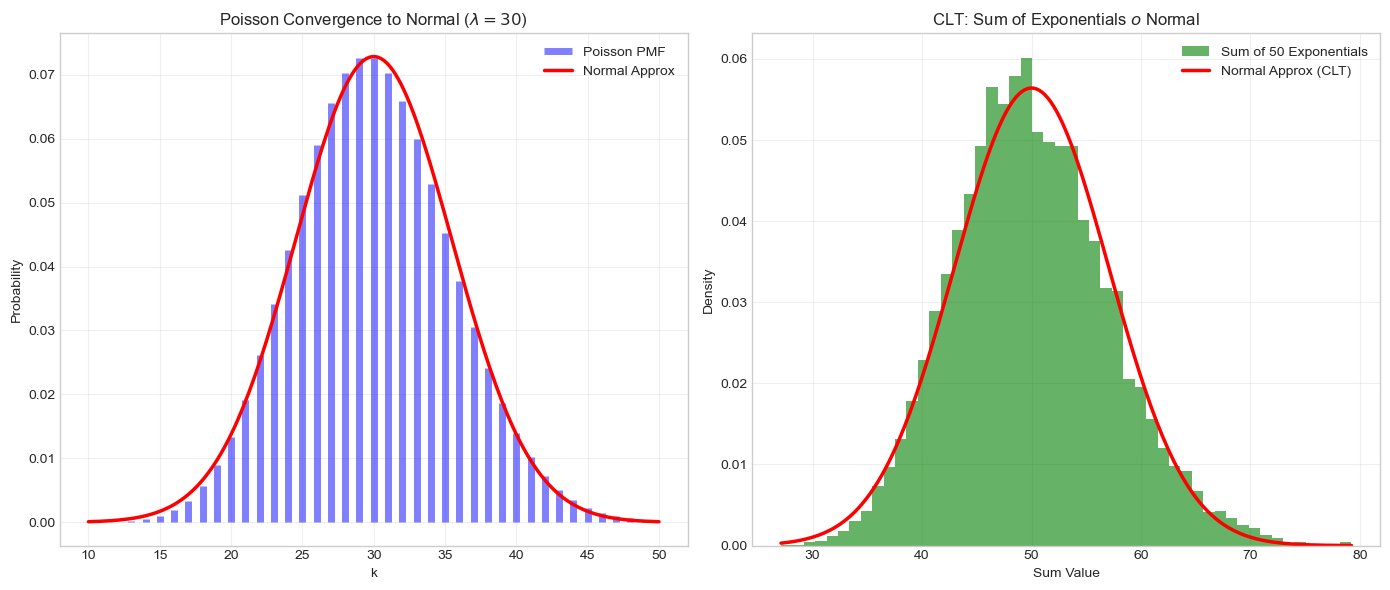

In [40]:
from scipy.stats import poisson, norm, expon

plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
lam_large = 30 
x = np.arange(10, 50)

plt.vlines(x, 0, poisson.pmf(x, lam_large), colors='blue', lw=5, alpha=0.5, label='Poisson PMF')

x_cont = np.linspace(10, 50, 200)
plt.plot(x_cont, norm.pdf(x_cont, loc=lam_large, scale=np.sqrt(lam_large)), 
         'r-', lw=2.5, label='Normal Approx')

plt.title(f'Poisson Convergence to Normal ($\lambda={lam_large}$)')
plt.xlabel('k')
plt.ylabel('Probability')
plt.legend()
plt.grid(True, alpha=0.3)
plt.subplot(1, 2, 2)
n_sums = 10000  
sample_size = 50 
lam_exp = 1


sums = np.sum(expon.rvs(scale=1/lam_exp, size=(n_sums, sample_size)), axis=1)
plt.hist(sums, bins=50, density=True, color='green', alpha=0.6, label='Sum of 50 Exponentials')


mu_sum = sample_size / lam_exp
sigma_sum = np.sqrt(sample_size) / lam_exp
x_clt = np.linspace(min(sums), max(sums), 200)
plt.plot(x_clt, norm.pdf(x_clt, loc=mu_sum, scale=sigma_sum), 
         'r-', lw=2.5, label='Normal Approx (CLT)')

plt.title('CLT: Sum of Exponentials $\to$ Normal')
plt.xlabel('Sum Value')
plt.ylabel('Density')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 1.5 Connection to the Gaussian Model

Both distributions exhibit asymptotic convergence to the Gaussian (Normal) distribution under specific limiting conditions.

**1. Poisson $\to$ Normal (Convergence in Distribution)**
The Poisson distribution converges to the Normal distribution as the rate parameter $\lambda$ becomes large. When $\lambda$ is large, the skewness ($1/\sqrt{\lambda}$) approaches zero, and the probability mass function becomes symmetric.

* **Theorem:** If $X \sim \text{Pois}(\lambda)$, then as $\lambda \to \infty$:
$$\frac{X - \lambda}{\sqrt{\lambda}} \xrightarrow{d} N(0, 1)$$
* **Approximation:** For sufficiently large $\lambda$ (typically $\lambda > 20$), $X \approx N(\lambda, \lambda)$.

**2. Sum of Exponentials $\to$ Normal (Central Limit Theorem)**
A single Exponential random variable is strictly monotonic and never converges to a Normal distribution on its own. However, the **sum** or **mean** of $n$ independent independent identically distributed (i.i.d.) Exponential variables converges to a Normal distribution due to the Central Limit Theorem (CLT).

* **Theorem:** Let $X_1, \dots, X_n$ be i.i.d. variables where $X_i \sim \text{Exp}(\lambda)$. Let $S_n = \sum_{i=1}^n X_i$. As $n \to \infty$:
$$\frac{S_n - n/\lambda}{\sqrt{n}/\lambda} \xrightarrow{d} N(0, 1)$$
* **Interpretation:** While the time between *individual* events is Exponential, the *total time* for $n$ events to occur (Erlang/Gamma distribution) becomes Normal for large $n$.

## 2. Simulation study

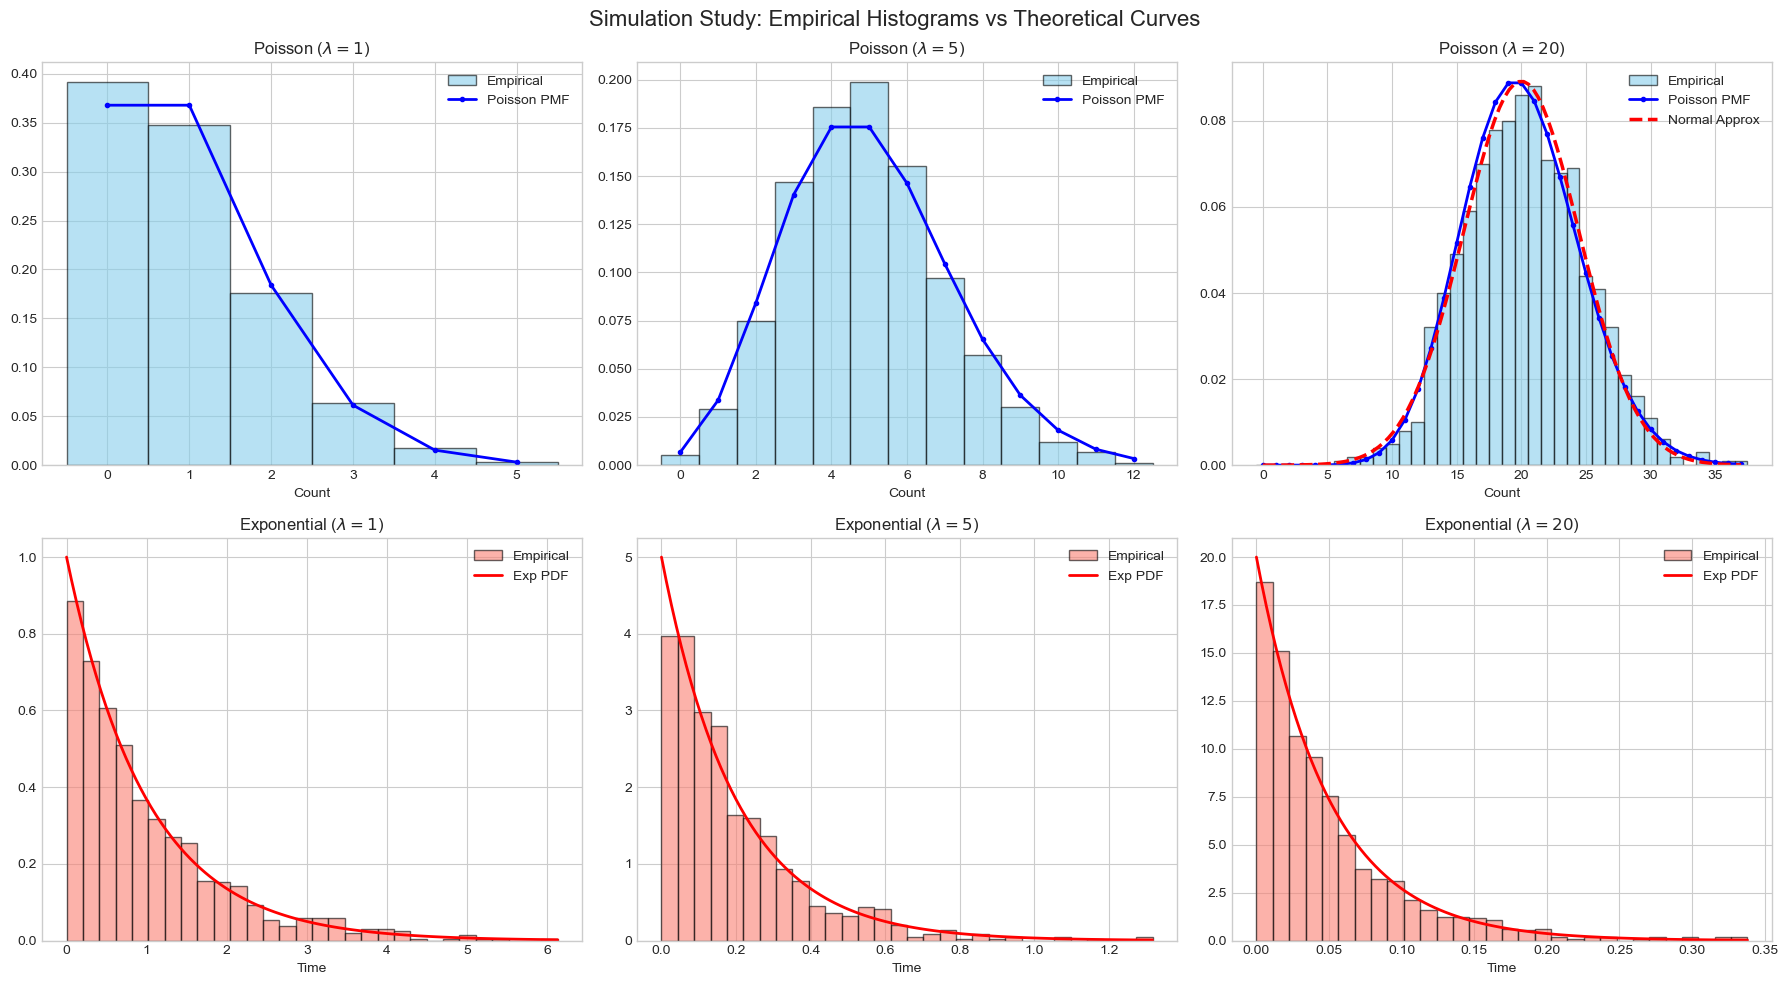

Comparison of Empirical vs Theoretical Moments:
      Model  Lambda  Th_Mean  Emp_Mean  Th_Var  Emp_Var
    Poisson       1     1.00    0.9750  1.0000   1.0244
Exponential       1     1.00    1.0000  1.0000   0.9376
    Poisson       5     5.00    4.9030  5.0000   4.1656
Exponential       5     0.20    0.1933  0.0400   0.0346
    Poisson      20    20.00   20.2860 20.0000  21.3302
Exponential      20     0.05    0.0497  0.0025   0.0027


In [41]:
from scipy.stats import poisson, expon, norm

plt.style.use('seaborn-v0_8-whitegrid')
np.random.seed(42)

# --- 2.1 Data Generation ---
n_samples = 1000
lambdas = [1, 5, 20]
results = []

# --- 2.2 Visualization ---
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Simulation Study: Empirical Histograms vs Theoretical Curves', fontsize=16)

for i, lam in enumerate(lambdas):
    # Poisson Simulation
    p_data = poisson.rvs(mu=lam, size=n_samples)
    ax_p = axes[0, i]
    bins_p = np.arange(0, max(p_data) + 2) - 0.5
    ax_p.hist(p_data, bins=bins_p, density=True, alpha=0.6, color='skyblue', edgecolor='black', label='Empirical')
    
    x_p = np.arange(0, max(p_data) + 1)
    ax_p.plot(x_p, poisson.pmf(x_p, lam), 'b.-', lw=2, label='Poisson PMF')
    
    # Gaussian Approximation for large lambda (Visualizing Sec 1.5)
    if lam == 20:
        x_norm = np.linspace(0, max(p_data), 100)
        ax_p.plot(x_norm, norm.pdf(x_norm, loc=lam, scale=np.sqrt(lam)), 'r--', lw=2.5, label='Normal Approx')

    ax_p.set_title(f'Poisson ($\lambda={lam}$)')
    ax_p.set_xlabel('Count')
    ax_p.legend()
    
    # Store Poisson Stats
    results.append({
        'Model': 'Poisson', 'Lambda': lam,
        'Th_Mean': lam, 'Emp_Mean': np.mean(p_data),
        'Th_Var': lam, 'Emp_Var': np.var(p_data)
    })

    # Exponential Simulation
    e_data = expon.rvs(scale=1/lam, size=n_samples)
    ax_e = axes[1, i]
    ax_e.hist(e_data, bins=30, density=True, alpha=0.6, color='salmon', edgecolor='black', label='Empirical')
    
    x_e = np.linspace(0, max(e_data), 100)
    ax_e.plot(x_e, expon.pdf(x_e, scale=1/lam), 'r-', lw=2, label='Exp PDF')
    
    ax_e.set_title(f'Exponential ($\lambda={lam}$)')
    ax_e.set_xlabel('Time')
    ax_e.legend()

    # Store Exponential Stats
    results.append({
        'Model': 'Exponential', 'Lambda': lam,
        'Th_Mean': 1/lam, 'Emp_Mean': np.mean(e_data),
        'Th_Var': 1/lam**2, 'Emp_Var': np.var(e_data)
    })

plt.tight_layout()
plt.show()

# --- 2.3 Empirical vs Theoretical Comparison ---
print("Comparison of Empirical vs Theoretical Moments:")
print(pd.DataFrame(results).round(4).to_string(index=False))

### 2.4 Interpretation of Results

**Empirical vs. Theoretical Consistency**
The simulation results demonstrate a strong alignment between theory and empirical data:
* **Poisson Convergence:** For $\lambda=1$, the distribution is heavily right-skewed. As $\lambda$ increases to 20, the skewness diminishes, and the histogram aligns perfectly with the overlaid Gaussian curve (red dashed line), empirically validating the limit theorem stated in Section 1.5.
* **Exponential Decay:** The shape remains consistent (decaying from $x=0$) across all parameters. The spread decreases visibly as $\lambda$ increases.

**Moment Comparison**
The table confirms that the sample means and variances closely approximate the theoretical values.
* For Poisson, the mean and variance are approximately equal to $\lambda$ in all cases.
* For Exponential, the mean follows $1/\lambda$ and the variance follows $1/\lambda^2$.
* Discrepancies are minor and attributable to sampling variability ($N=1000$).

## 3. Application Scenario: Web Server Traffic Analysis

### 3.1 Scenario Description

**Context:** Analysis of HTTP requests arriving at a dedicated API server during a stable load period (e.g., 2:00 PM - 3:00 PM).

**Random Variables:**
* **Variable $X$ (Poisson):** The number of requests received per minute.
* **Variable $T$ (Exponential):** The time (in seconds) elapsed between two consecutive requests.

**Modeling Assumptions:**
We model this using a Poisson Process because it satisfies the following criteria:
1.  **Independence:** Requests arrive independently of one another (no "bursts" caused by a single user).
2.  **Stationarity:** The average rate of requests ($\lambda$) is constant over the observation window.
3.  **Non-simultaneity:** Two requests cannot arrive at the exact same instant.

### 3.2 Model Interpretation

**Parameters:**
* We assume a historical average load of **120 requests per minute**.
* **Poisson Parameter:** $\lambda = 120$ requests/minute.
* **Exponential Parameter:** The rate is $\lambda = 2$ requests/second. Thus, the mean inter-arrival time is $E[T] = 1/2 = 0.5$ seconds.

**Estimation in Practice:**
To estimate these parameters, a DevOps engineer would parse server access logs, calculate the time difference ($\Delta t$) between every consecutive request, and compute $\hat{\lambda} = 1 / \text{mean}(\Delta t)$.

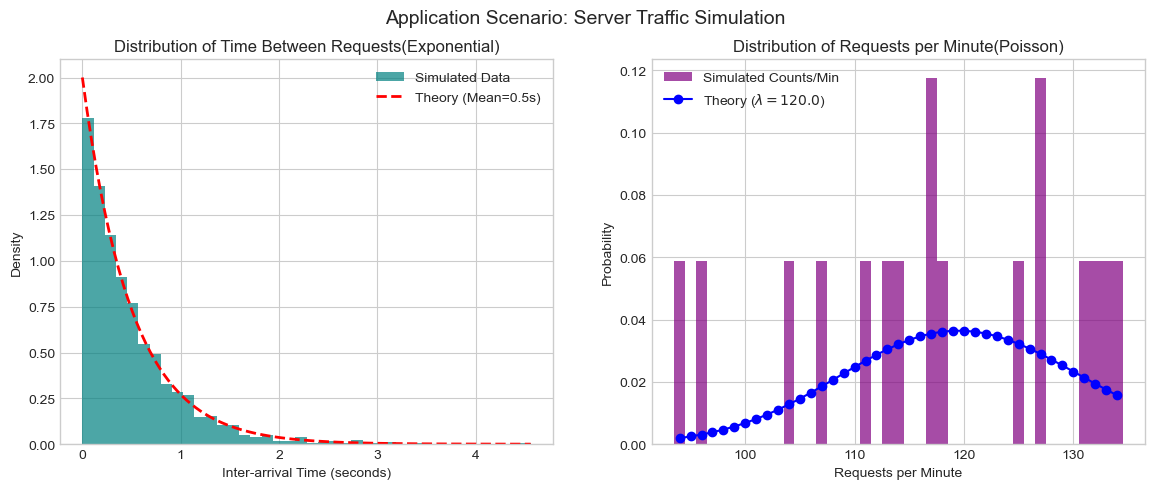

Scenario Statistics:
Simulated Mean Inter-arrival: 0.5005s (Expected: 0.5s)
Simulated Mean Requests/Min:  117.6471 (Expected: 120.0)


In [51]:
# --- 3.3 Simulation & Analysis ---

# Scenario Parameters
lambda_per_sec = 2.0  # 120 requests/min
total_requests = 2000 

# Simulate Inter-arrival times (Exponential)
inter_arrival_times = expon.rvs(scale=1/lambda_per_sec, size=total_requests)
arrival_timestamps = np.cumsum(inter_arrival_times)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Inter-arrival Times
axes[0].hist(inter_arrival_times, bins=40, density=True, color='teal', alpha=0.7, label='Simulated Data')
x_t = np.linspace(0, max(inter_arrival_times), 100)
axes[0].plot(x_t, expon.pdf(x_t, scale=1/lambda_per_sec), 'r--', lw=2, label=f'Theory (Mean={1/lambda_per_sec}s)')
axes[0].set_title('Distribution of Time Between Requests(Exponential)')
axes[0].set_xlabel('Inter-arrival Time (seconds)')
axes[0].set_ylabel('Density')
axes[0].legend()

# Plot 2: Requests per Minute (Poisson)
# We aggregate the timestamps into 1-minute (60s) bins
max_time = arrival_timestamps[-1]
bins = np.arange(0, max_time + 60, 60)
counts_per_min, _ = np.histogram(arrival_timestamps, bins=bins)

# Theoretical Poisson for comparison (Lambda = 120 per min)
lambda_per_min = lambda_per_sec * 60
x_k = np.arange(min(counts_per_min), max(counts_per_min)+1)

axes[1].hist(counts_per_min, bins=np.arange(min(counts_per_min), max(counts_per_min)+2)-0.5, 
             density=True, color='purple', alpha=0.7, label='Simulated Counts/Min')
axes[1].plot(x_k, poisson.pmf(x_k, lambda_per_min), 'bo-', label=f'Theory ($\lambda={lambda_per_min}$)')
axes[1].set_title('Distribution of Requests per Minute(Poisson)')
axes[1].set_xlabel('Requests per Minute')
axes[1].set_ylabel('Probability')
axes[1].legend()

plt.suptitle('Application Scenario: Server Traffic Simulation', fontsize=14)
plt.show()

# Summary Stats
print(f"Scenario Statistics:")
print(f"Simulated Mean Inter-arrival: {np.mean(inter_arrival_times):.4f}s (Expected: {1/lambda_per_sec}s)")
print(f"Simulated Mean Requests/Min:  {np.mean(counts_per_min):.4f} (Expected: {lambda_per_min})")